# Lab 2: Perceptron → Single Neuron
---
### Objective: Implement a single-neuron classifier from scratch and explore how activation functions affect learning and decision boundaries.

### Part A : Implement Perceptron (Step Activation) 

#### 1. Imports

In [23]:
import numpy as np
import matplotlib.pyplot as plt

#### 2. Generate Linearly Separable Dataset

In [34]:
np.random.seed(42)
class_0 = np.random.randn(100, 2) - 2
class_1 = np.random.randn(100, 2) + 2

X = np.vstack((class_0, class_1))
y = np.array([0]*100 + [1]*100)
y_step = np.where(y == 0, -1, 1)    # labels for step perceptron

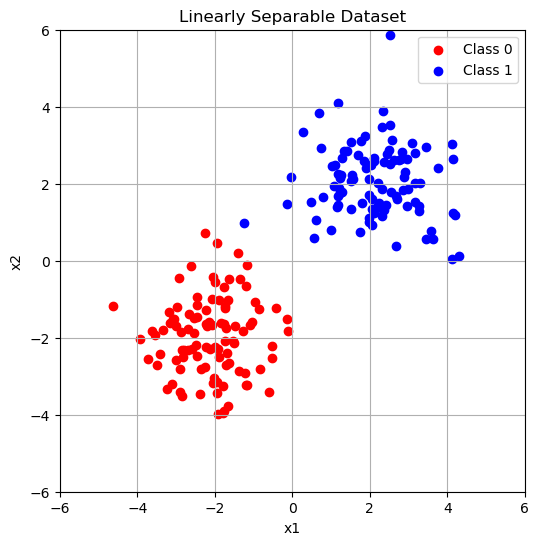

In [36]:
plt.figure(figsize=(6, 6))

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='red', label='Class 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='blue', label='Class 1')

plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Linearly Separable Dataset")
plt.legend()
plt.grid(True)
plt.show()


#### 3. Perceptron Components

In [37]:
# a. DOT PRODUCT
def dot_product(weights, inputs):
    return np.dot(weights, inputs)

# b. BIAS ADDITION
def add_bias(dot_output, bias):
    return dot_output + bias

# c. STEP ACTIVATION
def step_activation(value):
    return 1 if value >= 0 else -1

In [38]:
weights = np.array([0.0, 0.0])
bias = 0.0
x_sample = X[0]
y_sample = y_step[0]
z = dot_product(weights, x_sample)
z_bias = add_bias(z, bias)
prediction = step_activation(z_bias)
print("Input:", x_sample)
print("Dot Product:", z)
print("After Bias Addition:", z_bias)
print("Step Activation Output:", prediction)
print("True Label:", y_sample)

Input: [-1.50328585 -2.1382643 ]
Dot Product: 0.0
After Bias Addition: 0.0
Step Activation Output: 1
True Label: -1


#### 4. Train Using Perceptron Learning Rule

In [39]:
learning_rate = 0.01
epochs = 100
weights = np.random.randn(X.shape[1])
bias = 0.0
for epoch in range(epochs):
    for i in range(len(X)):
        z = dot_product(weights, X[i]) + bias
        y_pred = step_activation(z)

        if y_step[i] != y_pred:
            weights = weights + learning_rate * y_step[i] * X[i]
            bias = bias + learning_rate * y_step[i]
print("Trained Weights:", weights)
print("Trained Bias:", bias)

Trained Weights: [0.11583517 0.58470228]
Trained Bias: -0.40000000000000013


#### 5. Plot

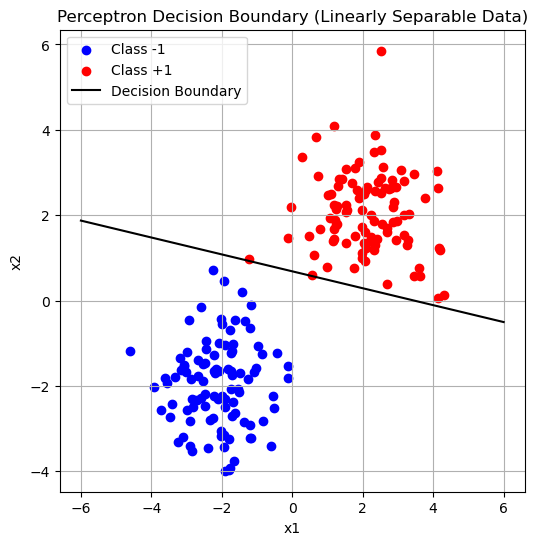

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y_step == -1][:, 0], X[y_step == -1][:, 1], color='blue', label='Class -1')
plt.scatter(X[y_step == 1][:, 0], X[y_step == 1][:, 1], color='red', label='Class +1')
x_vals = np.linspace(-6, 6, 100)
y_vals = -(weights[0] * x_vals + bias) / weights[1]
plt.plot(x_vals, y_vals, color='black', label='Decision Boundary')
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Perceptron Decision Boundary (Linearly Separable Data)")
plt.grid(True)
plt.show()

### Part B Single Neuron with Sigmoid
#### 6. Replace step activation with:

In [30]:
# a. Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [31]:
# b. Binary cross entropy (or MSE, your choice)
def binary_cross_entropy(y, y_hat):
    eps = 1e-9
    return -np.mean(y*np.log(y_hat + eps) + (1-y)*np.log(1-y_hat + eps))

#### 7. Train using gradient descent weight update (single neuron)

In [41]:
y = np.array([0]*100 + [1]*100)

In [42]:
w = np.zeros(X.shape[1])
b = 0.0
losses = []

for _ in range(epochs):
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    loss = binary_cross_entropy(y, y_hat)
    losses.append(loss)
    dw = np.dot(X.T, (y_hat - y)) / len(y)
    db = np.mean(y_hat - y)
    w -= learning_rate * dw
    b -= learning_rate * db

#### 8. Plot:

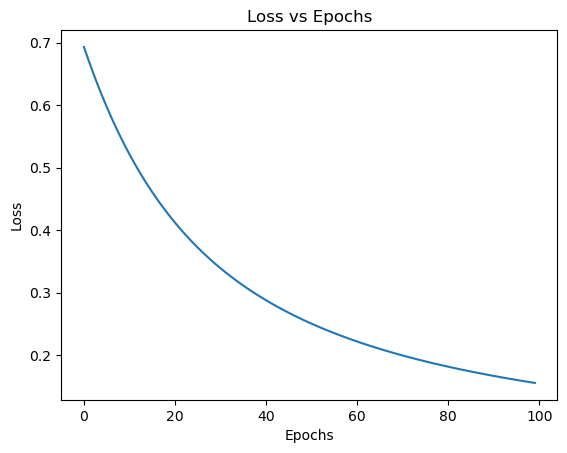

In [43]:
# a. loss vs epochs
plt.figure()
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()

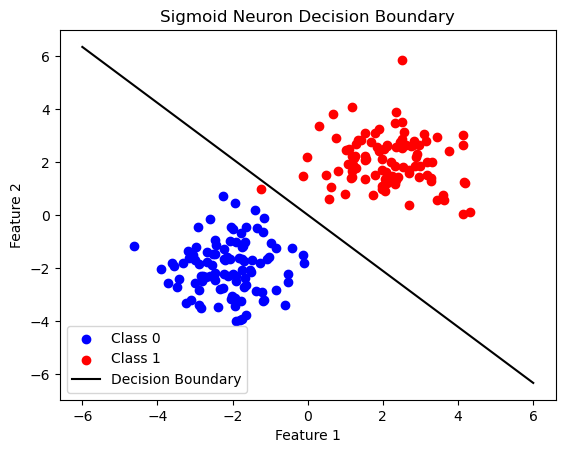

In [44]:
# b PLOT DATASET + DECISION BOUNDARY
plt.figure()
plt.scatter(class_0[:, 0], class_0[:, 1], color="blue", label="Class 0")
plt.scatter(class_1[:, 0], class_1[:, 1], color="red", label="Class 1")

x_vals = np.linspace(-6, 6, 100)
y_vals = -(w[0] * x_vals + b) / w[1]
plt.plot(x_vals, y_vals, color="black", label="Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.title("Sigmoid Neuron Decision Boundary")
plt.show()

#### 9.Accuracy comparison (Step vs Sigmoid)

In [45]:
step_predictions = np.array([
    1 if np.dot(w, x) + b >= 0 else -1
    for x in X
])
step_accuracy = np.mean(step_predictions == y_step)

# Accuracy for SIGMOID
sigmoid_predictions = (sigmoid(np.dot(X, w) + b) >= 0.5).astype(int)
sigmoid_accuracy = np.mean(sigmoid_predictions == y)

print("Step (Perceptron) Accuracy:", step_accuracy)
print("Sigmoid Neuron Accuracy:", sigmoid_accuracy)


Step (Perceptron) Accuracy: 0.995
Sigmoid Neuron Accuracy: 0.995


### Part C: Compare on Linear vs XOR dataset 
#### 10. Run BOTH models (Step-perceptron and Sigmoid-neuron) on:

In [47]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor_sig = np.array([0, 1, 1, 0])          # for sigmoid
y_xor_step = np.where(y_xor_sig == 0, -1, 1)

- STEP-PERCEPTRON ON XOR

In [49]:
step_preds_xor = np.array([
    1 if np.dot(weights, x) + bias >= 0 else -1
    for x in X_xor
])
step_acc_xor = np.mean(step_preds_xor == y_xor_step)

- SIGMOID NEURON ON XOR

In [51]:
sig_preds_xor = (sigmoid(np.dot(X_xor, w) + b) >= 0.5).astype(int)
sig_acc_xor = np.mean(sig_preds_xor == y_xor_sig)


print("STEP Perceptron Accuracy on XOR:", step_acc_xor)
print("Sigmoid Neuron Accuracy on XOR:", sig_acc_xor)

STEP Perceptron Accuracy on XOR: 0.5
Sigmoid Neuron Accuracy on XOR: 0.75


### a. Accuracy Results

#### Linearly Separable Dataset
- Step Perceptron: High accuracy (≈ 100%)
- Sigmoid Neuron: High accuracy (≈ 100%)
#### XOR Dataset
- Step Perceptron: Low accuracy (≈ 50%)
- Sigmoid Neuron: Low accuracy (≈ 50%)

---

### b. Reason for Failure on XOR Dataset
- The XOR problem is not linearly separable.
- A single neuron can learn only linear decision boundaries.
- Both step and sigmoid activations produce linear separators for a single neuron.
- XOR requires a non-linear decision boundary, which needs multiple neurons (hidden layer).